In [2]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.045315097261362].


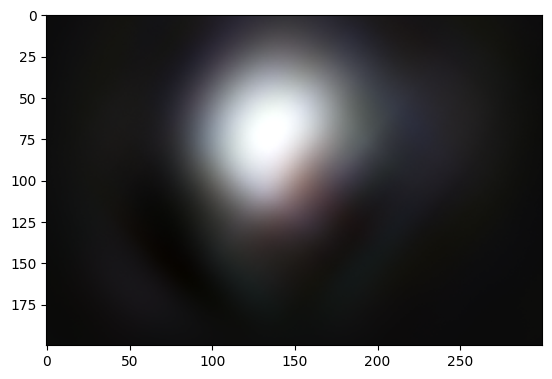

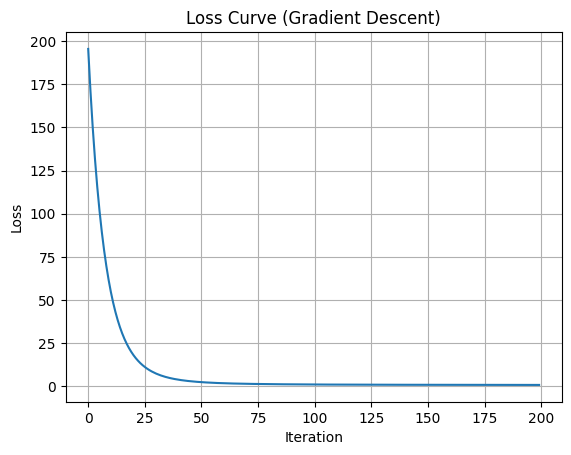

In [3]:
import matplotlib.pyplot as plt
import numpy as np 
from inverse_solver import InverseSolver

psf = (plt.imread('img/IMG_0273.jpg').astype(np.float64)) / 255.0
dif = (plt.imread('img/IMG_0276.jpg').astype(np.float64)) / 255.0

psf = psf[::20, ::20, :]
y = dif[::20, ::20, :]

solver = InverseSolver(
    psf,
    algorithm="gradient_descent",
    num_iters=200,
)

gd = solver(y)

gd = (gd - gd.min()) / (gd.max() + 1e-8)

plt.imshow(gd)

plt.figure()
plt.plot(solver.losses)
plt.title("Loss Curve (Gradient Descent)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

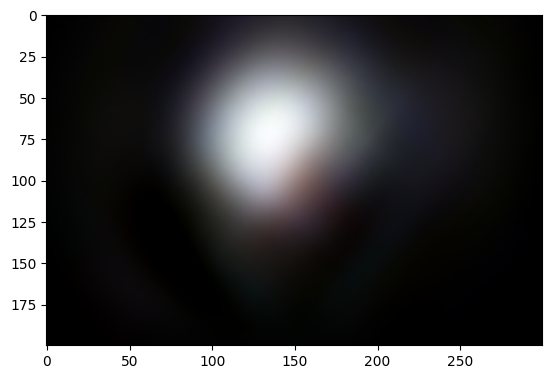

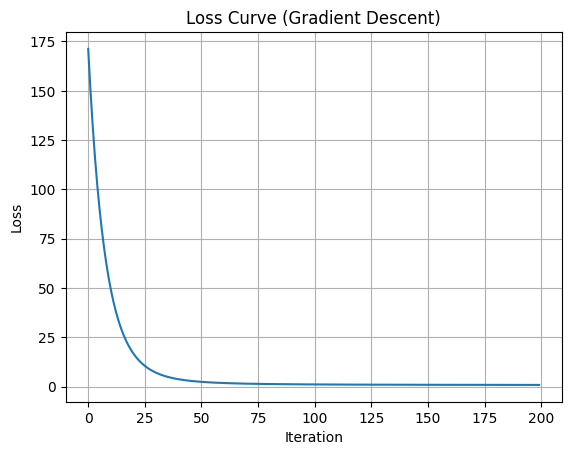

In [4]:
import matplotlib.pyplot as plt

psf = (plt.imread('img/IMG_0273.jpg').astype(np.float64)) / 255.0
dif = (plt.imread('img/IMG_0276.jpg').astype(np.float64)) / 255.0

psf = psf[::20, ::20, :]
y = dif[::20, ::20, :]

solver = InverseSolver(
    psf,
    algorithm="ista",
    num_iters=200,
    prox_fn=InverseSolver.prox_nonneg,
    lam = 1e-2
)

ista = solver(y)

ista = (ista - ista.min()) / (ista.max() + 1e-8)


plt.imshow(ista)

plt.figure()
plt.plot(solver.losses)
plt.title("Loss Curve (Gradient Descent)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

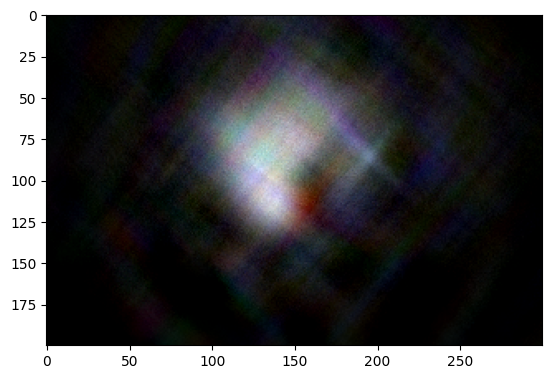

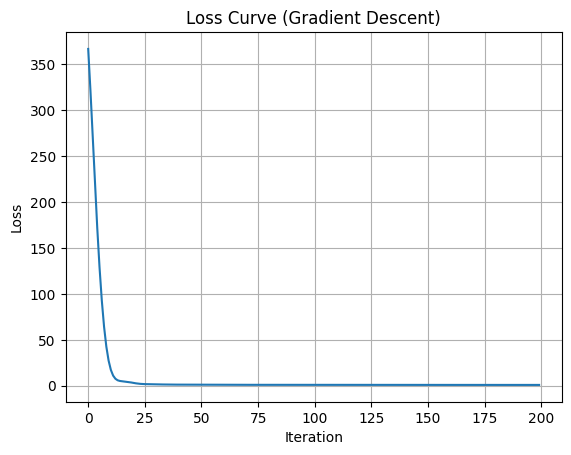

In [5]:

psf = (plt.imread('img/IMG_0272.jpg').astype(np.float64)) / 255.0
dif = (plt.imread('img/IMG_0274.jpg').astype(np.float64)) / 255.0

psf = psf[::20, ::20, :]
y = dif[::20, ::20, :]

solver = InverseSolver(
    psf,
    algorithm="fista",
    num_iters=200,
    prox_fn=InverseSolver.prox_nonneg,
    lam = 1e-2
)

fista = solver(y)

fista = (fista - fista.min()) / (fista.max() + 1e-8)

plt.imshow(fista)

plt.figure()
plt.plot(solver.losses)
plt.title("Loss Curve (Gradient Descent)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.045315097261362].


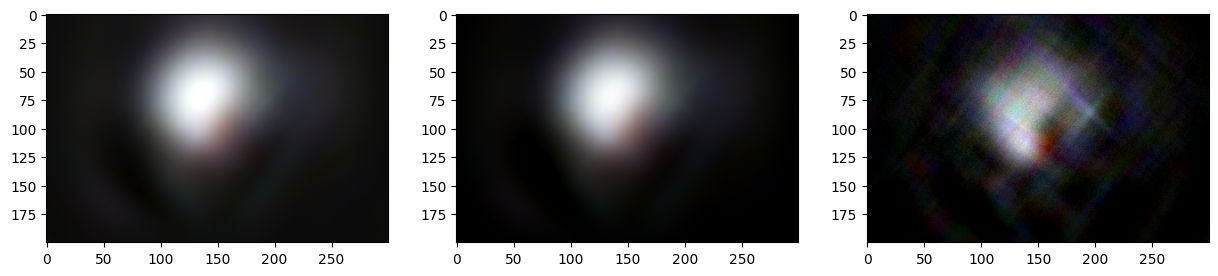

In [6]:
f, axarr = plt.subplots(1, 3, figsize=(15, 5))
axarr[0].imshow(gd)
axarr[1].imshow(ista)
axarr[2].imshow(fista)

In [7]:
def run_experiment(solver_type, y_measurement, psf_data):
    # Initialize solver
    solver = InverseSolver(
        psf=psf_data, 
        algorithm=solver_type, 
        prox_fn=InverseSolver.prox_nonneg, 
        num_iters=1
    )
    
    x = np.zeros((y_measurement.shape[0] * 2, y_measurement.shape[1] * 2, y_measurement.shape[2]))
    v = np.zeros_like(x)
    t = 1.0
    
    loss_history = []
    max_iters = 500
    epsilon = 1e-3
    
    for i in range(max_iters):
        # Call the specific update methods from your class
        if solver_type == "gradient_descent":
            x, loss = solver.gd_update(x, y_measurement)
        elif solver_type == "ista":
            x, loss = solver.ista_update(x, y_measurement)
        elif solver_type == "fista":
            v, t, x, loss = solver.fista_update(v, t, x, y_measurement)
            
        loss_history.append(loss)
        
        # Convergence Check
        if i > 0:
            rel_change = abs(loss_history[-1] - loss_history[-2]) / loss_history[-2]
            if rel_change < epsilon:
                print(f"  -> Converged in {i+1} iterations.")
                break
                
    return solver.crop(x), loss_history, i+1

_, _, fista_iters = run_experiment("fista", y, psf)
_, _, ista_iters = run_experiment("ista", y, psf)  

print(f"FISTA converged in {fista_iters} iterations.")
print(f"ISTA converged in {ista_iters} iterations.")

  -> Converged in 111 iterations.
  -> Converged in 231 iterations.
FISTA converged in 111 iterations.
ISTA converged in 231 iterations.


FISTA Sparsity + Non-Negativity

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0002503780132517].


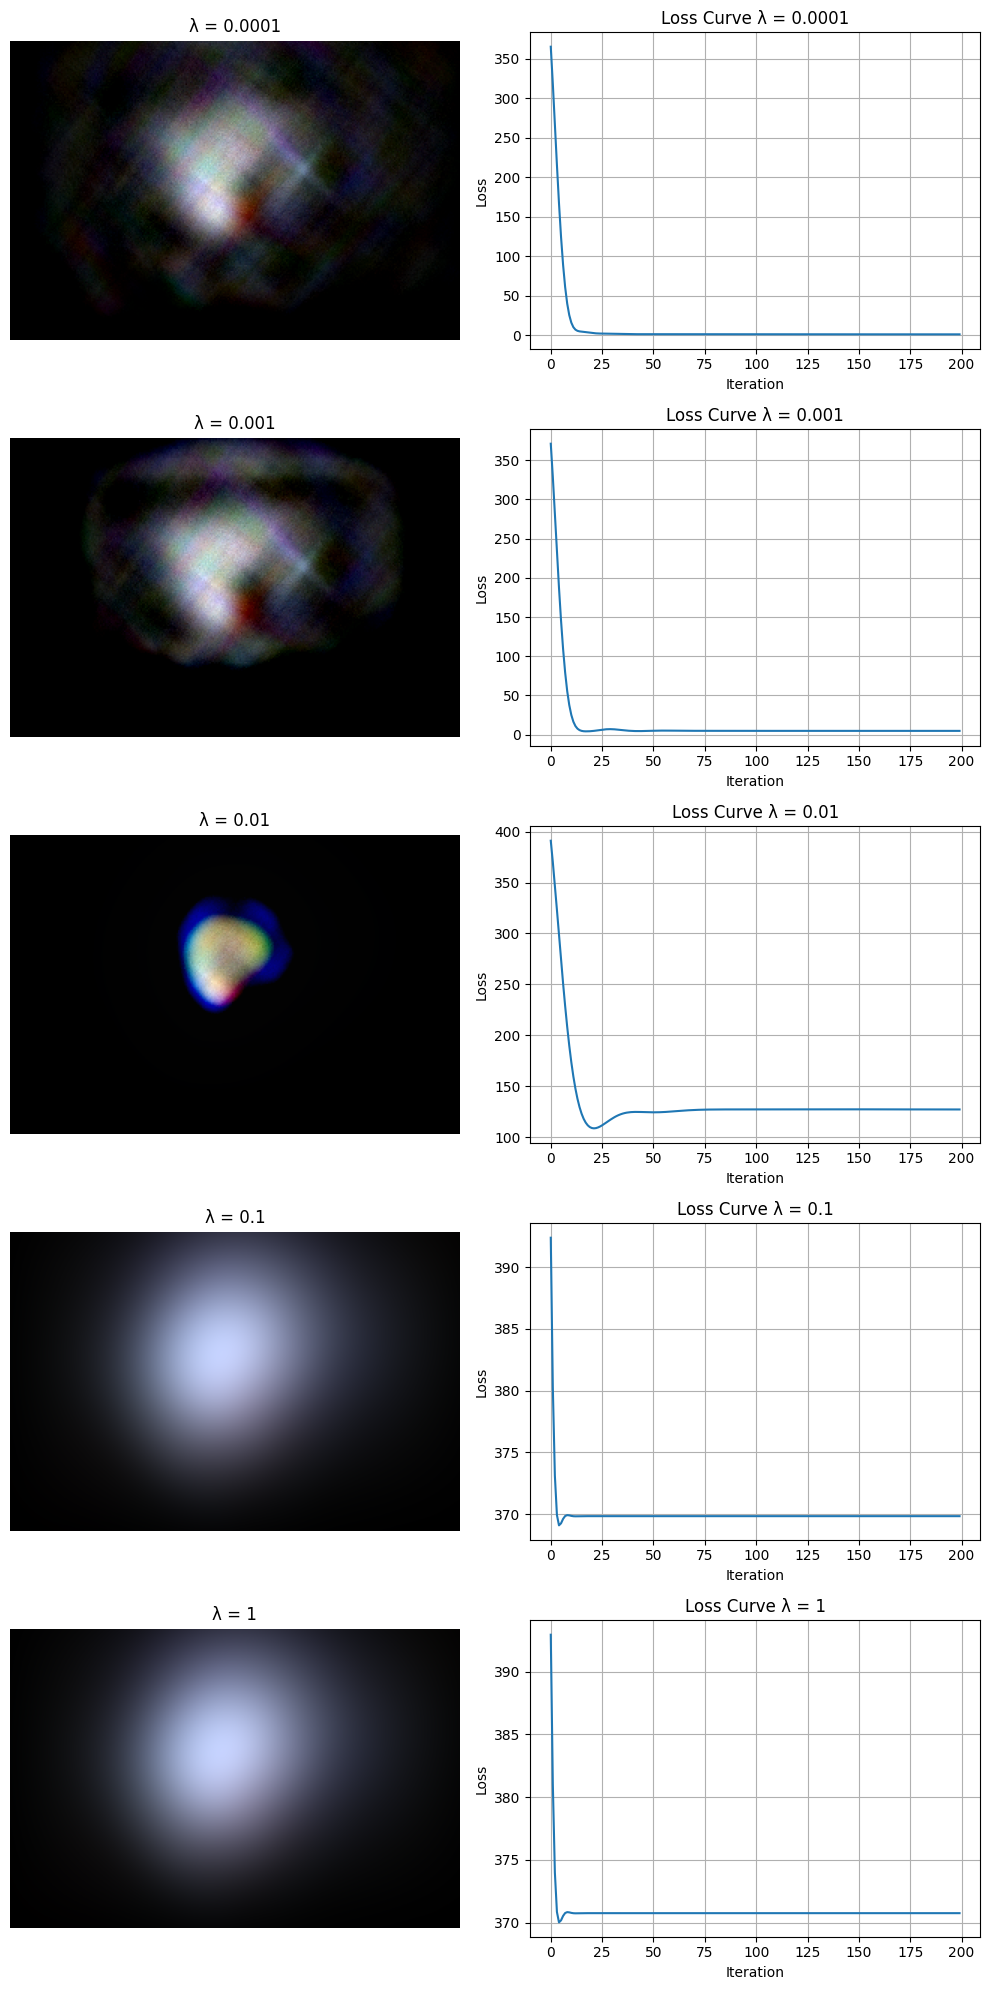

In [8]:
from priors import prox_native
psf = (plt.imread('img/IMG_0272.jpg').astype(np.float64)) / 255.0
dif = (plt.imread('img/IMG_0274.jpg').astype(np.float64)) / 255.0

psf = psf[::20, ::20, :]
y = dif[::20, ::20, :]

lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1]

fig, axes = plt.subplots(len(lambdas), 2, figsize=(10, 4*len(lambdas)))

for i, lam in enumerate(lambdas):
    solver = InverseSolver(psf, algorithm="fista", num_iters=200, prox_fn=prox_native, lam=lam)
    fista = solver(y)
    fista = (fista - fista.min()) / (fista.max() + 1e-8)
    
    axes[i, 0].imshow(fista)
    axes[i, 0].set_title(f"λ = {lam}")
    axes[i, 0].axis('off')
    
    axes[i, 1].plot(solver.losses)
    axes[i, 1].set_title(f"Loss Curve λ = {lam}")
    axes[i, 1].set_xlabel("Iteration")
    axes[i, 1].set_ylabel("Loss")
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()